In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm scikit-learn seaborn matplotlib transformers pillow

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import os
import copy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
import seaborn as sns
from transformers import pipeline

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_json = {
    "username": "dulakshalk",
    "key": "KGAT_d7d5e658a6aa63a46e56a04eca1de3fb"
}

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
 97% 639M/658M [00:01<00:00, 279MB/s]
100% 658M/658M [00:03<00:00, 180MB/s]


In [6]:
data_dir = "/content/data/PlantVillage"

Total images  : 20638
Total classes : 15
Classes       : ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


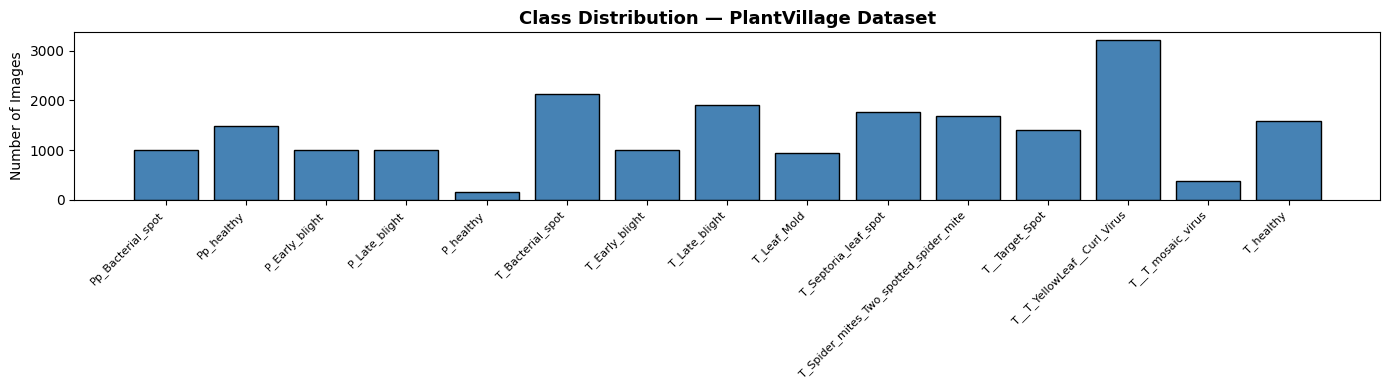

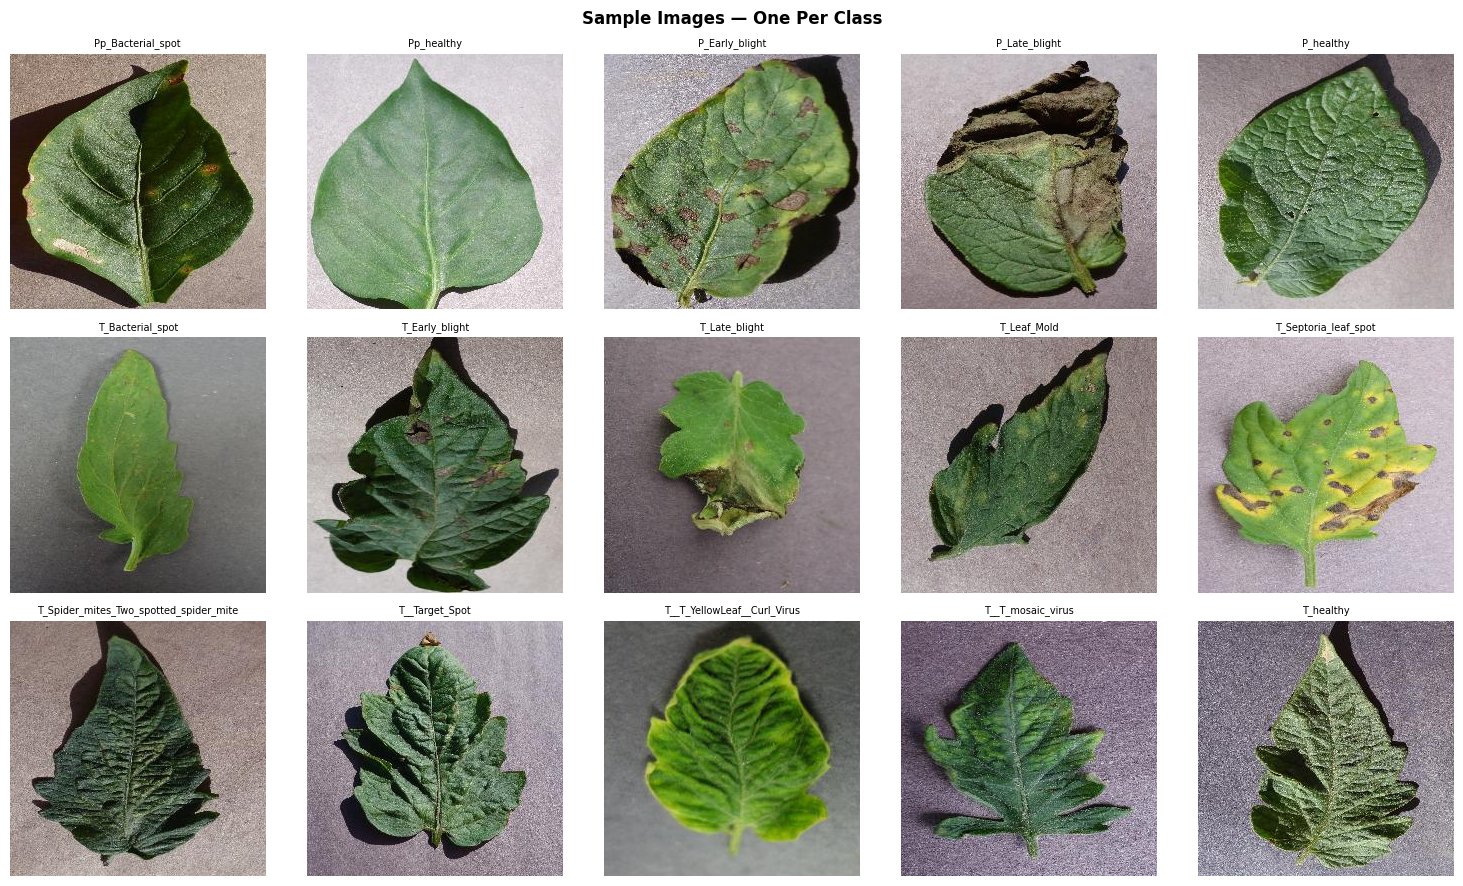

In [7]:
# ==============================
# DATASET EXPLORATION
# Shows class distribution and sample images
# ==============================

explore_dataset = datasets.ImageFolder(data_dir)
class_names     = explore_dataset.classes
num_classes     = len(class_names)
labels_array    = np.array(explore_dataset.targets)

print(f"Total images  : {len(explore_dataset)}")
print(f"Total classes : {num_classes}")
print(f"Classes       : {class_names}")

# Class distribution bar chart
counts      = [(cls, int((labels_array == i).sum())) for i, cls in enumerate(class_names)]
short_names = [c[0].replace("Tomato_","T_").replace("Potato___","P_").replace("Pepper__bell___","Pp_") for c in counts]

plt.figure(figsize=(14, 4))
plt.bar(range(len(counts)), [c[1] for c in counts], color='steelblue', edgecolor='black')
plt.xticks(range(len(counts)), short_names, rotation=45, ha='right', fontsize=8)
plt.title("Class Distribution — PlantVillage Dataset", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# Sample images — one per class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, cls in enumerate(class_names):
    cls_dir   = os.path.join(data_dir, cls)
    img_file  = os.listdir(cls_dir)[0]
    img       = Image.open(os.path.join(cls_dir, img_file)).convert("RGB")
    axes[i//5][i%5].imshow(img)
    axes[i//5][i%5].set_title(short_names[i], fontsize=7)
    axes[i//5][i%5].axis("off")
plt.suptitle("Sample Images — One Per Class", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ==============================
# PREPROCESSING & DATA SPLITS
# Resize, augment, normalize — then split 70% train / 15% val / 15% test
# ==============================

IMG_SIZE   = 224
BATCH_SIZE = 32

# Training: augmentation to simulate real field conditions
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation/Test: only resize and normalize (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Stratified split — ensures equal class representation in all splits
full_dataset = datasets.ImageFolder(data_dir)
class_names  = full_dataset.classes
num_classes  = len(class_names)
labels       = full_dataset.targets
indices      = list(range(len(labels)))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
temp_labels         = [labels[i] for i in temp_idx]
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

train_dataset = Subset(datasets.ImageFolder(data_dir, transform=train_transform),    train_idx)
val_dataset   = Subset(datasets.ImageFolder(data_dir, transform=val_test_transform), val_idx)
test_dataset  = Subset(datasets.ImageFolder(data_dir, transform=val_test_transform), test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train : {len(train_idx)} images")
print(f"Val   : {len(val_idx)} images")
print(f"Test  : {len(test_idx)} images")
print(f"Classes: {num_classes}")

Train : 14446 images
Val   : 3096 images
Test  : 3096 images
Classes: 15


In [9]:
# ==============================
# TRAINING FUNCTION
# Used for both EfficientNet and ViT
# Includes: early stopping, LR scheduler, overfitting detection
# ==============================

def train_model(model, model_name):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    best_model_weights = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    patience_limit = 3
    counter = 0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    EPOCHS = 10

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # --- Training phase ---
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # --- Validation phase ---
        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (preds == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc  = correct / total

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc:  {train_acc:.4f}  | Val Acc:  {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if train_acc - val_acc > 0.15:
            print("⚠️  Overfitting detected (train/val gap > 15%)")

        if val_loss < best_loss:
            best_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
        if counter >= patience_limit:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), f"{model_name}_best.pth")

    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses,   label='Val Loss')
    ax1.set_title(f"{model_name} — Loss Curve")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True)

    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs,   label='Val Accuracy')
    ax2.set_title(f"{model_name} — Accuracy Curve")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{model_name}_training_curves.png")
    plt.show()

    return model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 172MB/s]



Epoch 1/10


Validation: 100%|██████████| 97/97 [00:15<00:00,  6.37it/s]


Train Loss: 0.6703 | Val Loss: 0.0864
Train Acc:  0.8222  | Val Acc:  0.9755

Epoch 2/10


...

Train Loss: 0.0368 | Val Loss: 0.0139
Train Acc:  0.9883  | Val Acc:  0.9958

Epoch 9/10


Validation: 100%|██████████| 97/97 [00:09<00:00, 10.73it/s]


Train Loss: 0.0273 | Val Loss: 0.0125
Train Acc:  0.9920  | Val Acc:  0.9952

Epoch 10/10


Validation: 100%|██████████| 97/97 [00:09<00:00, 10.09it/s]


Train Loss: 0.0225 | Val Loss: 0.0095
Train Acc:  0.9933  | Val Acc:  0.9977


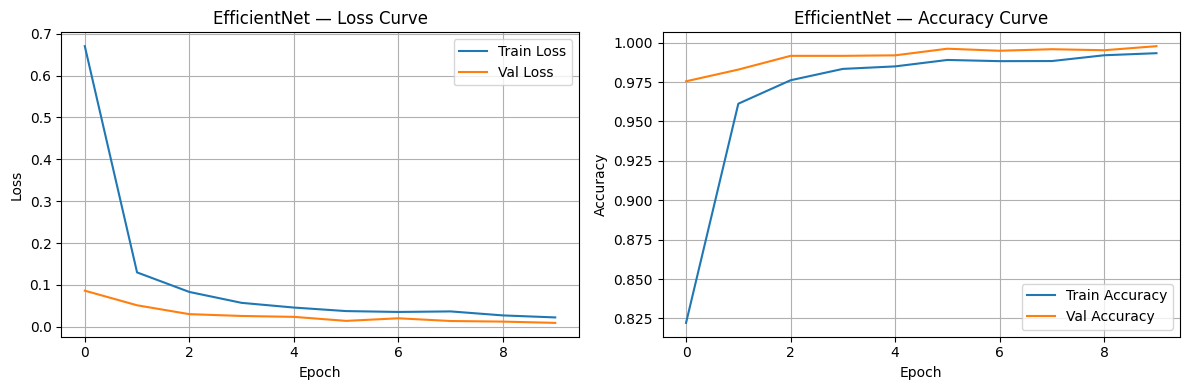

In [10]:
# ==============================
# MODEL 1: EfficientNet-B0 (Transfer Learning)
# Pretrained on ImageNet — fine-tuned for plant disease classification
# ==============================

model_eff = models.efficientnet_b0(pretrained=True)
model_eff.classifier[1] = nn.Linear(model_eff.classifier[1].in_features, num_classes)
model_eff = model_eff.to(device)

model_eff = train_model(model_eff, "EfficientNet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Epoch 1/10


Validation: 100%|██████████| 97/97 [00:35<00:00,  2.72it/s]


Train Loss: 0.3232 | Val Loss: 0.1551
Train Acc:  0.8951  | Val Acc:  0.9532

Epoch 2/10


...

Train Loss: 0.0585 | Val Loss: 0.1839
Train Acc:  0.9814  | Val Acc:  0.9457

Epoch 7/10


Validation: 100%|██████████| 97/97 [00:35<00:00,  2.73it/s]


Train Loss: 0.0699 | Val Loss: 0.0694
Train Acc:  0.9776  | Val Acc:  0.9764

Epoch 8/10


Validation: 100%|██████████| 97/97 [00:35<00:00,  2.72it/s]


Train Loss: 0.0599 | Val Loss: 0.0653
Train Acc:  0.9805  | Val Acc:  0.9774
Early stopping triggered.


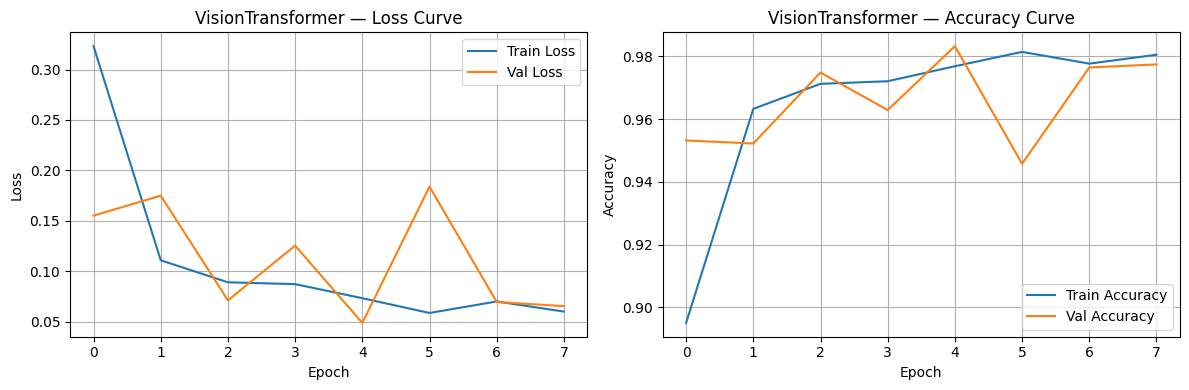

In [11]:
# ==============================
# MODEL 2: Vision Transformer ViT-B/16 (Transfer Learning)
# Self-attention captures global leaf patterns CNNs may miss
# ==============================

model_vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
model_vit = model_vit.to(device)

model_vit = train_model(model_vit, "VisionTransformer")


  EfficientNet — Test Set Results
  Accuracy  : 0.9926
  Precision : 0.9926
  Recall    : 0.9926
  F1-Score  : 0.9926

EfficientNet — Per-Class Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     1.0000    1.0000    1.0000       149
                     Pepper__bell___healthy     0.9955    1.0000    0.9977       221
                      Potato___Early_blight     1.0000    1.0000    1.0000       150
                       Potato___Late_blight     1.0000    0.9933    0.9967       150
                           Potato___healthy     0.9583    1.0000    0.9787        23
                      Tomato_Bacterial_spot     0.9937    0.9843    0.9890       319
                        Tomato_Early_blight     0.9799    0.9733    0.9766       150
                         Tomato_Late_blight     0.9965    0.9826    0.9895       287
                           Tomato_Leaf_Mold     1.0000    1.0000 

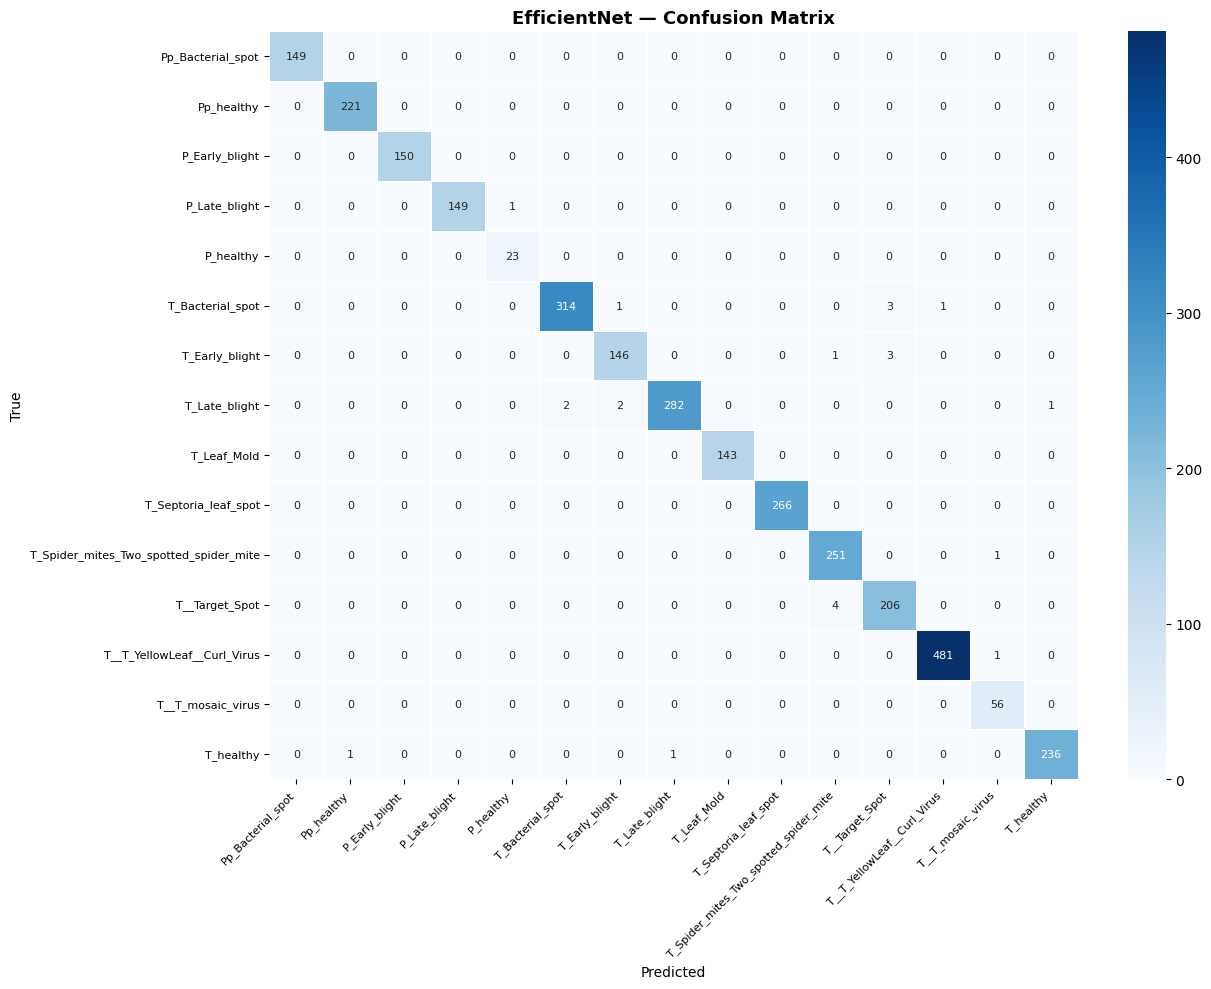


  VisionTransformer — Test Set Results
  Accuracy  : 0.9848
  Precision : 0.9851
  Recall    : 0.9848
  F1-Score  : 0.9848

VisionTransformer — Per-Class Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9933    0.9933    0.9933       149
                     Pepper__bell___healthy     0.9955    0.9955    0.9955       221
                      Potato___Early_blight     0.9934    1.0000    0.9967       150
                       Potato___Late_blight     0.9739    0.9933    0.9835       150
                           Potato___healthy     1.0000    1.0000    1.0000        23
                      Tomato_Bacterial_spot     0.9723    0.9906    0.9814       319
                        Tomato_Early_blight     0.9733    0.9733    0.9733       150
                         Tomato_Late_blight     0.9894    0.9791    0.9842       287
                           Tomato_Leaf_Mold     1.0000 

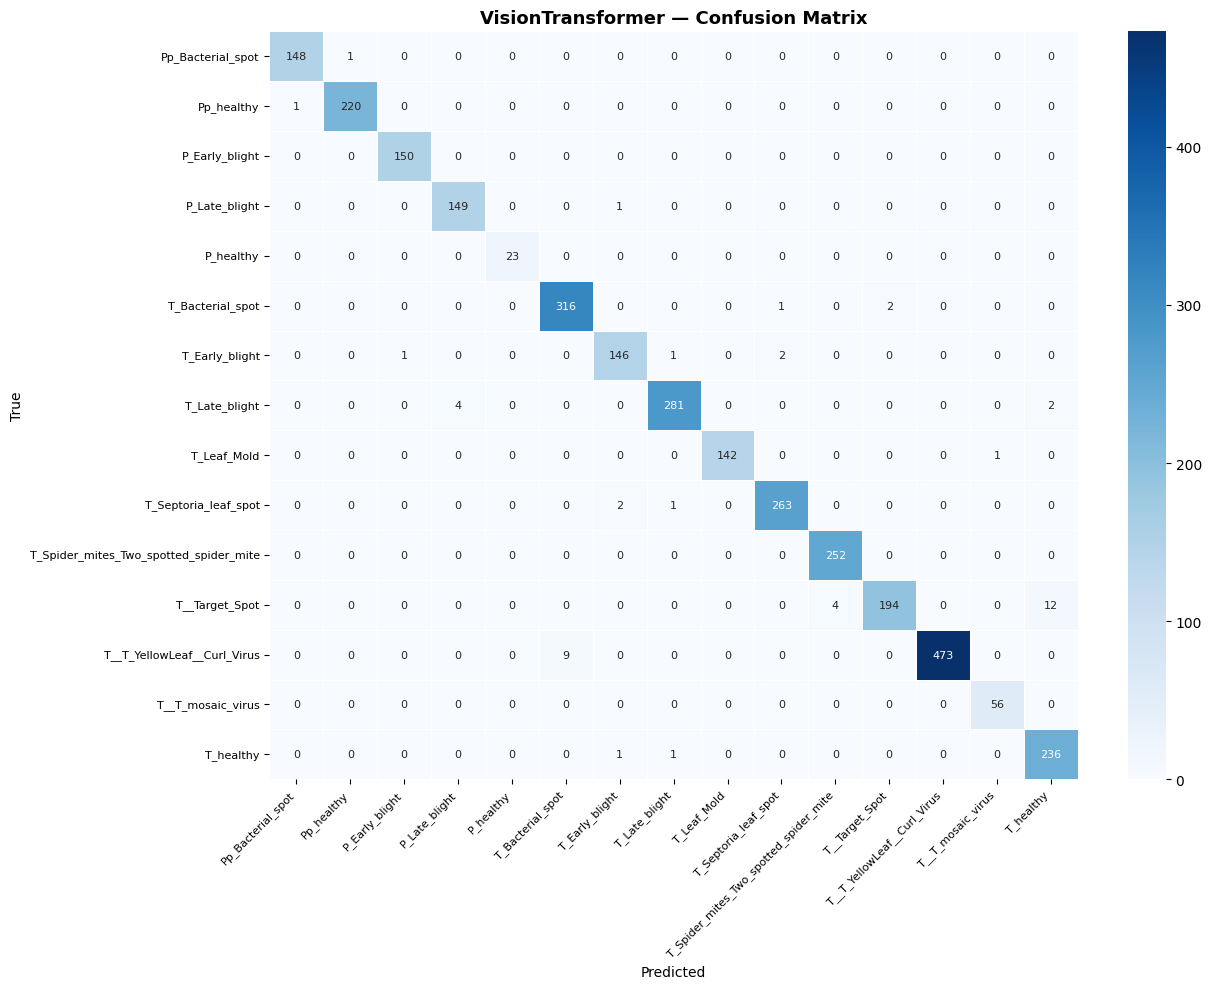

In [12]:
# ==============================
# EVALUATE BOTH MODELS
# Accuracy, Precision, Recall, F1 + per-class report + confusion matrix
# ==============================

def evaluate(model, name):
    model.eval()
    preds_list, labels_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.numpy())

    acc       = accuracy_score(labels_list, preds_list)
    precision = precision_score(labels_list, preds_list, average='weighted', zero_division=0)
    recall    = recall_score(labels_list,    preds_list, average='weighted', zero_division=0)
    f1        = f1_score(labels_list,        preds_list, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {name} — Test Set Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*50}")
    print(f"\n{name} — Per-Class Classification Report:\n")
    print(classification_report(labels_list, preds_list, target_names=class_names, digits=4))

    # Confusion matrix with numbers
    short = [c.replace("Tomato_","T_").replace("Potato___","P_").replace("Pepper__bell___","Pp_") for c in class_names]
    cm = confusion_matrix(labels_list, preds_list)
    plt.figure(figsize=(13, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=short, yticklabels=short,
                linewidths=0.4, annot_kws={"size": 8})
    plt.title(f"{name} — Confusion Matrix", fontsize=13, fontweight='bold')
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix.png", dpi=150)
    plt.show()

    return acc, precision, recall, f1


eff_results = evaluate(model_eff, "EfficientNet")
vit_results = evaluate(model_vit, "VisionTransformer")

                   Model  Accuracy  Precision   Recall  F1-Score
         EfficientNet-B0  0.992571   0.992633 0.992571  0.992578
Vision Transformer (ViT)  0.984819   0.985087 0.984819  0.984794


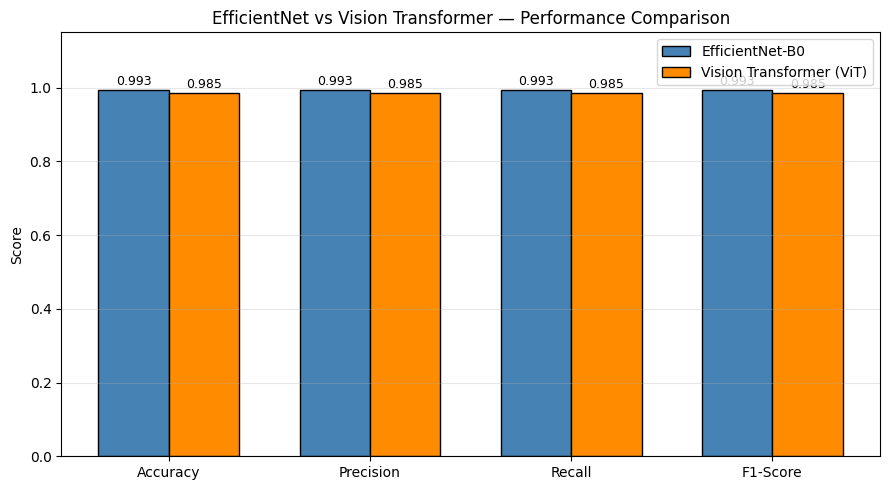

In [15]:
# ==============================
# MODEL COMPARISON — Side-by-side bar chart
# ==============================

comparison = pd.DataFrame({
    "Model":     ["EfficientNet-B0", "Vision Transformer (ViT)"],
    "Accuracy":  [eff_results[0], vit_results[0]],
    "Precision": [eff_results[1], vit_results[1]],
    "Recall":    [eff_results[2], vit_results[2]],
    "F1-Score":  [eff_results[3], vit_results[3]],
})
print(comparison.to_string(index=False))
comparison.to_csv("model_comparison.csv", index=False)

metrics  = ["Accuracy", "Precision", "Recall", "F1-Score"]
eff_vals = [eff_results[0], eff_results[1], eff_results[2], eff_results[3]]
vit_vals = [vit_results[0], vit_results[1], vit_results[2], vit_results[3]]
x        = range(len(metrics))
width    = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i - width/2 for i in x], eff_vals, width, label='EfficientNet-B0',         color='steelblue',  edgecolor='black')
b2 = ax.bar([i + width/2 for i in x], vit_vals, width, label='Vision Transformer (ViT)', color='darkorange', edgecolor='black')

for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("EfficientNet vs Vision Transformer — Performance Comparison")
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()

In [17]:
# ==============================
# LLM ADVISORY SYSTEM + AGRICULTURAL ONTOLOGY
# Fixed: loads Flan-T5 directly (pipeline text2text-generation removed in newer transformers)
# ==============================

from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

print("Loading Flan-T5 LLM...")
tokenizer  = T5Tokenizer.from_pretrained("google/flan-t5-base")
llm_model  = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")
llm_model.eval()
print("LLM ready.")

def run_llm(prompt):
    inputs  = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=150,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# AGROVOC ontology — FAO standard (https://agrovoc.fao.org)
agrovoc_ontology = {
    "Pepper__bell___Bacterial_spot":               "AGROVOC c_72352 — Bacterial spot (Xanthomonas campestris)",
    "Pepper__bell___healthy":                      "AGROVOC c_5873  — Healthy plant tissue",
    "Potato___Early_blight":                       "AGROVOC c_25158 — Early blight (Alternaria solani)",
    "Potato___Late_blight":                        "AGROVOC c_25159 — Late blight (Phytophthora infestans)",
    "Potato___healthy":                            "AGROVOC c_5873  — Healthy plant tissue",
    "Tomato_Bacterial_spot":                       "AGROVOC c_72352 — Bacterial spot (Xanthomonas vesicatoria)",
    "Tomato_Early_blight":                         "AGROVOC c_25158 — Early blight (Alternaria solani)",
    "Tomato_Late_blight":                          "AGROVOC c_25159 — Late blight (Phytophthora infestans)",
    "Tomato_Leaf_Mold":                            "AGROVOC c_4871  — Leaf mold (Passalora fulva)",
    "Tomato_Septoria_leaf_spot":                   "AGROVOC c_6925  — Septoria leaf spot (Septoria lycopersici)",
    "Tomato_Spider_mites_Two_spotted_spider_mite": "AGROVOC c_7345  — Spider mite (Tetranychus urticae)",
    "Tomato__Target_Spot":                         "AGROVOC c_4871  — Target spot (Corynespora cassiicola)",
    "Tomato__Tomato_YellowLeaf__Curl_Virus":       "AGROVOC c_92411 — Tomato yellow leaf curl virus (Begomovirus)",
    "Tomato__Tomato_mosaic_virus":                 "AGROVOC c_92412 — Tomato mosaic virus (Tobamovirus)",
    "Tomato_healthy":                              "AGROVOC c_5873  — Healthy plant tissue",
}

disease_info = {
    "Pepper__bell___Bacterial_spot":               {"cause": "Xanthomonas campestris bacteria.",         "remedy": "Remove infected leaves. Apply copper-based spray.",     "prevention": "Use resistant varieties. Avoid overhead irrigation."},
    "Pepper__bell___healthy":                      {"cause": "No disease detected.",                     "remedy": "Maintain balanced watering and nutrition.",             "prevention": "Routine monitoring and farm hygiene."},
    "Potato___Early_blight":                       {"cause": "Alternaria solani fungus.",                 "remedy": "Neem oil spray. Remove lower infected leaves.",         "prevention": "Crop rotation. Proper plant spacing."},
    "Potato___Late_blight":                        {"cause": "Phytophthora infestans pathogen.",          "remedy": "Apply copper or mancozeb fungicide immediately.",       "prevention": "Plant certified disease-free seed potatoes."},
    "Potato___healthy":                            {"cause": "No disease detected.",                     "remedy": "Maintain soil fertility with compost.",                "prevention": "Regular field monitoring."},
    "Tomato_Bacterial_spot":                       {"cause": "Xanthomonas vesicatoria bacteria.",        "remedy": "Copper hydroxide spray. Remove plant debris.",          "prevention": "Use disease-free seed. Avoid leaf wetness."},
    "Tomato_Early_blight":                         {"cause": "Alternaria solani fungus.",                 "remedy": "Neem oil or chlorothalonil fungicide.",                "prevention": "Crop rotation. Remove infected leaf debris."},
    "Tomato_Late_blight":                          {"cause": "Phytophthora infestans fungus.",            "remedy": "Apply metalaxyl fungicide. Remove infected tissue.",   "prevention": "Avoid humidity. Plant resistant varieties."},
    "Tomato_Leaf_Mold":                            {"cause": "Passalora fulva fungus (high humidity).",  "remedy": "Improve airflow. Apply chlorothalonil fungicide.",      "prevention": "Maintain low humidity. Prune for airflow."},
    "Tomato_Septoria_leaf_spot":                   {"cause": "Septoria lycopersici fungus.",             "remedy": "Remove infected leaves. Apply neem oil.",              "prevention": "Avoid overhead watering. Mulch soil."},
    "Tomato_Spider_mites_Two_spotted_spider_mite": {"cause": "Tetranychus urticae mite infestation.",    "remedy": "Insecticidal soap or abamectin miticide.",             "prevention": "Control humidity. Introduce predatory mites."},
    "Tomato__Target_Spot":                         {"cause": "Corynespora cassiicola fungus.",           "remedy": "Remove affected leaves. Apply azoxystrobin.",          "prevention": "Field sanitation. Avoid dense planting."},
    "Tomato__Tomato_YellowLeaf__Curl_Virus":       {"cause": "Begomovirus transmitted via whiteflies.",  "remedy": "Control whiteflies with yellow sticky traps.",         "prevention": "Use resistant varieties. Install reflective mulch."},
    "Tomato__Tomato_mosaic_virus":                 {"cause": "Tobamovirus spread by contact.",           "remedy": "Remove and destroy infected plants immediately.",      "prevention": "Sanitize tools with bleach. Wash hands between plants."},
    "Tomato_healthy":                              {"cause": "No disease detected.",                     "remedy": "Balanced NPK fertilization.",                         "prevention": "Regular inspection. Maintain good airflow."},
}

def generate_advice(disease):
    info     = disease_info.get(disease)
    ontology = agrovoc_ontology.get(disease, "Unknown")

    if info is None:
        print(f"No advisory data for: {disease}")
        return

    prompt = (
        f"Disease: {disease.replace('_', ' ')}. "
        f"Cause: {info['cause']} "
        f"Remedy: {info['remedy']} "
        f"Prevention: {info['prevention']} "
        f"Write a short helpful advisory for a farmer."
    )
    llm_text = run_llm(prompt)

    print(f"\nDisease      : {disease.replace('_', ' ')}")
    print(f"Ontology Ref : {ontology}")
    print(f"Cause        : {info['cause']}")
    print(f"Remedy       : {info['remedy']}")
    print(f"Prevention   : {info['prevention']}")
    print(f"LLM Advisory : {llm_text}")
    print("-" * 60)

# Test
generate_advice("Tomato_Early_blight")
generate_advice("Tomato__Tomato_YellowLeaf__Curl_Virus")
generate_advice("Potato___Late_blight")

Loading Flan-T5 LLM...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LLM ready.

Disease      : Tomato Early blight
Ontology Ref : AGROVOC c_25158 — Early blight (Alternaria solani)
Cause        : Alternaria solani fungus.
Remedy       : Neem oil or chlorothalonil fungicide.
Prevention   : Crop rotation. Remove infected leaf debris.
LLM Advisory : Tomato Early blight. Cause: Alternaria solani fungus. Remedy: Neem oil or chlorothalonil fungicide. Prevention: Crop rotation.
------------------------------------------------------------

Disease      : Tomato  Tomato YellowLeaf  Curl Virus
Ontology Ref : AGROVOC c_92411 — Tomato yellow leaf curl virus (Begomovirus)
Cause        : Begomovirus transmitted via whiteflies.
Remedy       : Control whiteflies with yellow sticky traps.
Prevention   : Use resistant varieties. Install reflective mulch.
LLM Advisory : Tomato Tomato YellowLeaf Curl Virus. Cause: Begomovirus transmitted via whiteflies. Remedy: Control whiteflies with yellow sticky traps. Prevention: Use resistant varieties.
------------------------------

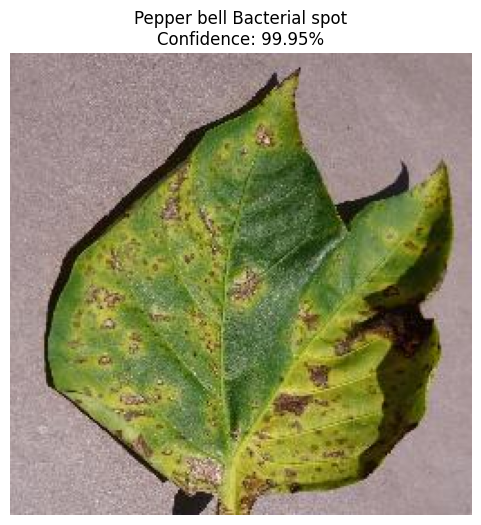

Predicted Disease : Pepper bell Bacterial spot
Confidence        : 99.95%

=== Agricultural Advisory ===

Disease      : Pepper  bell   Bacterial spot
Ontology Ref : AGROVOC c_72352 — Bacterial spot (Xanthomonas campestris)
Cause        : Xanthomonas campestris bacteria.
Remedy       : Remove infected leaves. Apply copper-based spray.
Prevention   : Use resistant varieties. Avoid overhead irrigation.
LLM Advisory : Xanthomonas campestris is a bacterium that can inflict bacterial spots on pepper bells. Xanthomonas campestris is a bacterium that can inflict bacterial spots on pepper bells. Xanthomonas campestris is a bacterium that can inflict bacterial spots on pepper bells. Xanthomonas campestris can inflict bactericidal spots on pepper bells. Xanthomonas campestris can inflict bactericidal spots on pepper bells.
------------------------------------------------------------


In [25]:
# ==============================
# TEST A SINGLE IMAGE
# Predicts disease + shows confidence + runs LLM advisory
# ==============================

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def clean_class_name(name):
    name = name.replace("___", " ").replace("__", " ").replace("_", " ")
    return name.strip()

def test_single_image(image_path):
    model_eff.eval()
    image      = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs    = model_eff(img_tensor)
        probs      = F.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    predicted_class_raw = class_names[pred.item()]
    predicted_class     = clean_class_name(predicted_class_raw)
    confidence_score    = confidence.item() * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"{predicted_class}\nConfidence: {confidence_score:.2f}%")
    plt.axis("off")
    plt.show()

    print("Predicted Disease :", predicted_class)
    print(f"Confidence        : {confidence_score:.2f}%")
    print("\n=== Agricultural Advisory ===")
    generate_advice(predicted_class_raw)


# Example — change the path to any image you want to test
test_single_image("/content/data/PlantVillage/Pepper__bell___Bacterial_spot/01dfb88b-cd5a-420c-b163-51f5fe07b74d___JR_B.Spot 9091.JPG")

In [20]:
# ==============================
# SAVE MODELS
# ==============================

save_dir = "final_saved_models"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_eff.state_dict(), os.path.join(save_dir, "efficientnet_best.pth"))
torch.save(model_vit.state_dict(), os.path.join(save_dir, "vit_best.pth"))

with open(os.path.join(save_dir, "class_names.json"), "w") as f:
    json.dump(class_names, f)

print("Models saved successfully.")

Models saved successfully.


In [ ]:
# ==============================
# SAVE MODELS FOR STREAMLIT APP
# Run this AFTER training is complete
# ==============================
import os, json, torch

save_dir = "final_saved_models"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_eff.state_dict(), os.path.join(save_dir, "efficientnet_best.pth"))
torch.save(model_vit.state_dict(), os.path.join(save_dir, "vit_best.pth"))

with open(os.path.join(save_dir, "class_names.json"), "w") as f:
    json.dump(class_names, f)

# Download the folder to your PC
import shutil
shutil.make_archive("final_saved_models", 'zip', "final_saved_models")
from google.colab import files
files.download("final_saved_models.zip")
files.download("app.py")

print("All files downloaded!")

In [ ]:
pip install streamlit timm transformers torch torchvision pillow
streamlit run app.py
